<a href="https://colab.research.google.com/github/camiloch28/ConnectaTel-analysis/blob/main/ConnectaTel_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

RTA/

Valores nulos — users

city (11.73% nulos): Está en el rango de 5–30%, por lo que amerita investigación antes de decidir. Recomiendo imputar como "Unknown" o "Sin dato" en vez de eliminar filas, ya que perder 469 usuarios (11.7% de la base) para el resto del análisis sería una pérdida de información significativa; mejor tratarlo como categoría explícita.
churn_date (88.35% nulos): Aunque cae en el rango "ignorar/eliminar" según la regla general, este nulo no es un dato faltante real — representa usuarios que siguen activos (no se han dado de baja). La acción correcta no es imputar ni eliminar, sino dejarlo como está y, si es útil, crear una columna derivada booleana como is_active (True si churn_date es nulo, False si tiene fecha) para usarla directamente en la segmentación.

Valores nulos — usage

date (0.13% nulos): Proporción mínima (<5%), caso simple. Recomiendo eliminar esas 50 filas, ya que sin fecha no se puede ubicar el evento en el tiempo y el impacto de perderlas es prácticamente nulo sobre 40,000 registros.
duration (55.19% nulos) y length (44.74% nulos): A primera vista caen en un rango que "no calza" bien con la regla general, pero la explicación real es estructural, no de calidad: duration aplica solo a registros de tipo llamada y length solo a tipo mensaje, por lo que cada fila usa naturalmente una sola de las dos columnas. No se deben imputar ni eliminar — son nulos esperados por diseño. Se recomienda verificarlo con un cruce usage.groupby('type')[['duration','length']].count() antes de dar esto por sentado en el reporte final.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Es un identificador numérico secuencial entre 10000 y 13999, sin valores negativos ni atípicos. Su media y mediana son casi iguales, lo cual es coherente con un ID asignado de forma uniforme — no requiere ninguna acción de limpieza.
- La columna `age` Presenta un valor mínimo de -999, lo cual es imposible como edad real y corresponde claramente a un sentinel value (probablemente usado para marcar datos faltantes o erróneos). Esto también infla artificialmente el std (123.23) del resumen estadístico. Acción recomendada: reemplazar -999 por NaN con .replace(-999, np.nan), y luego decidir si se imputa (por ejemplo con la mediana) o se deja como nulo explícito, dependiendo de cuántos registros se vean afectados.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`Ambas son identificadores numéricos consistentes: id es secuencial de 1 a 40000 sin anomalías, y user_id está dentro del mismo rango que en users (10000–13999), lo que confirma que ambos datasets se pueden relacionar correctamente. No requieren limpieza.
- Las columnas duration muestra un rango razonable (0 a 120) sin valores negativos ni sentinels evidentes. length va de 0 a 1490, donde el máximo resulta llamativo si se trata de longitud de mensajes de texto.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print("Frecuencia absoluta")
    print(users[col].value_counts())
    print("Frecuencia relativa")
    print(users[col].value_counts(normalize = True))
    print()


city
Frecuencia absoluta
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Frecuencia relativa
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64

plan
Frecuencia absoluta
Basico     2595
Premium    1405
Name: plan, dtype: int64
Frecuencia relativa
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64



- La columna `city` Contiene 6 ciudades válidas de México y Colombia (Bogotá, CDMX, Medellín, GDL, Cali, MTY), sin inconsistencias de formato. Sin embargo, se detectaron 96 registros con el valor "?", un sentinel de texto que representa datos faltantes mal codificados (no se cuenta como NaN en pandas, por lo que no apareció en el conteo de nulos anterior). Sumado a los 469 NaN ya identificados, el total real de registros sin ciudad válida es de 565 (14.1%). Acción recomendada: reemplazar "?" por NaN con .replace('?', np.nan), y luego tratar ambos casos de forma unificada (imputar como "Unknown" o dejar como nulo explícito).
- La columna `plan` Contiene únicamente 2 valores válidos (Basico 64.9%, Premium 35.1%), consistentes con los 2 planes del dataset plans. No requiere limpieza.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` Contiene 2 categorías (text con 22,092 registros y call con 17,908), cuyos conteos coinciden casi exactamente con los valores no-nulos de length y duration respectivamente. Esto confirma que los nulos en duration y length son estructurales (cada fila representa un solo tipo de evento) y no un problema real de calidad de datos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

RTA/ Se identificaron dos sentinels claros durante la exploración estadística y categórica:

age (en users): valor mínimo de -999, imposible como edad real. Este sentinel también infla artificialmente la desviación estándar de la columna (123.23), distorsionando cualquier estadística descriptiva calculada sobre ella.
city (en users): valor "?" presente en 96 registros, usado como marcador de "sin dato". A diferencia de age, este sentinel es de tipo texto, por lo que no fue detectado por .isna() — solo se hizo visible al revisar .value_counts() de la columna categórica. Sumado a los 469 NaN ya existentes, el total de registros sin ciudad válida asciende a 565 (14.1% del dataset).

No se encontraron sentinels evidentes en plans, plan, type, duration (0–120, rango razonable) ni en los identificadores (user_id, id). La columna length tiene un máximo de 1490, que no es un sentinel per se, pero es un valor atípico a revisar más adelante en el análisis de outliers (paso de visualización).

- ¿Qué acción tomarías?

RTA/ age = -999 → Reemplazar por NaN con .replace(-999, np.nan), y luego imputar con la mediana de la columna (más robusta que la media, ya que la media está afectada por el propio sentinel antes de limpiarlo) o dejar como nulo explícito según cuántos registros estén afectados.
city = "?" → Reemplazar por NaN con .replace('?', np.nan), y unificar su tratamiento con los 469 NaN ya existentes — imputando como categoría "Unknown" o dejándolos como nulos explícitos, dependiendo de si city será clave para la segmentación final.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, Se detectaron 40 registros con año 2026, una fecha imposible dado que el negocio solo tiene datos registrados hasta 2024 — probablemente un error de captura o de sistema (posiblemente relacionado con el mismo tipo de problema que generó el sentinel -999 en age). El resto de los registros se distribuye de forma razonable entre 2022, 2023 y 2024, con conteos similares entre los tres años (~1,300 cada uno), lo cual sugiere una tasa de adquisición de clientes estable a lo largo del tiempo.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date,`Todos los 39,950 registros con fecha válida corresponden al año 2024, sin fechas futuras ni imposibles. Esto es coherente con que usage registra actividad reciente de los clientes, concentrada en el período de análisis vigente del negocio.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

RTA/ Sí, se encontraron 40 registros en reg_date con año 2026 (fecha futura imposible). La acción tomada fue marcarlos como NaT (nulo específico para fechas) en lugar de eliminar las filas completas, ya que el resto de la información del usuario (edad, ciudad, plan) sigue siendo válida y útil para el análisis de segmentación. No se encontraron fechas imposibles en date (usage), donde el 100% de los registros válidos corresponden a 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

RTA/ Al cruzar los nulos de duration y length con el tipo de evento (type), queda claro que no estamos ante un problema real de calidad de datos, sino ante la forma en que está diseñada la tabla. Cada fila de usage representa un solo evento: o es una llamada, o es un mensaje de texto, nunca ambos a la vez. Por eso, cuando el evento es una llamada, tiene sentido que length quede vacío (no aplica medir "longitud" en una llamada), y cuando es un mensaje de texto, es normal que duration quede vacío (un mensaje no tiene "duración" como una llamada).

En otras palabras, estos nulos dependen completamente de otra columna que sí conocemos (type), lo cual es la definición exacta de un valor MAR (Missing At Random): no es aleatorio en el sentido de "sin explicación", sino que su ausencia se explica por completo por otra variable observada del propio dataset.

Decisión: se dejan estos valores como nulos (NaN), sin imputar ni eliminar filas. Imputar un valor de duration para un mensaje de texto (o viceversa) sería inventar un dato que no debería existir, y eliminar la fila completa haría perder información válida de user_id, type y date que sí es útil para el análisis. Para futuros cálculos (por ejemplo, promedio de duración de llamadas), simplemente se debe filtrar por type == 'call' antes de operar sobre duration, y de forma equivalente para length con los mensajes.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    total_mensajes=("is_text", "sum"),
    total_llamadas=("is_call", "sum"),
    total_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_mensajes,total_llamadas,total_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "total_mensajes": "cant_mensajes",
    "total_llamadas": "cant_llamadas",
    "total_minutos_llamada": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

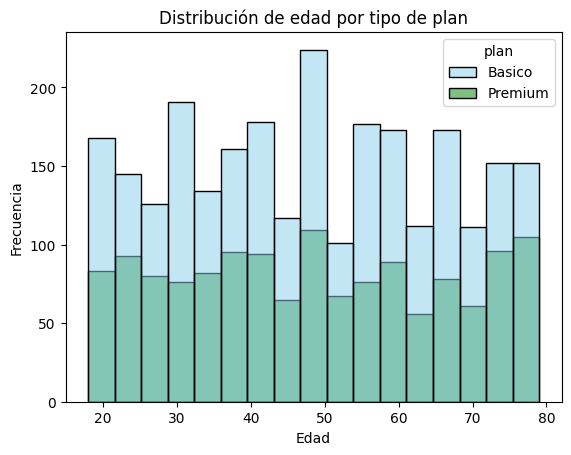

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Distribución relativamente pareja entre planes, sin una edad claramente asociada a un plan en particular."

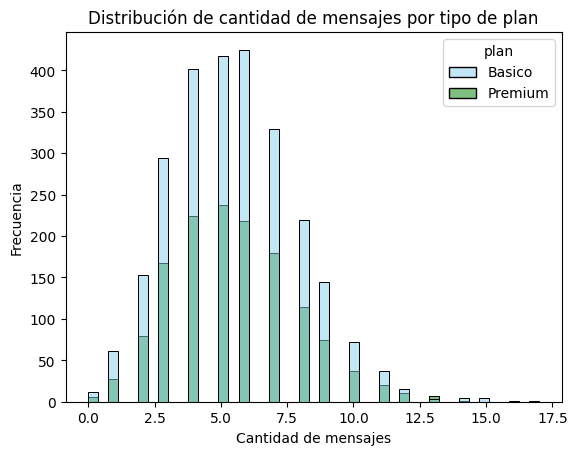

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Con el gráfico real, se ve que ambos planes siguen una distribución similar, sesgada a la derecha (la mayoría envía entre 3 y 7 mensajes, pocos usuarios superan 12). No hay una diferencia marcada entre Básico y Premium — ambos muestran el mismo patrón de forma proporcional.

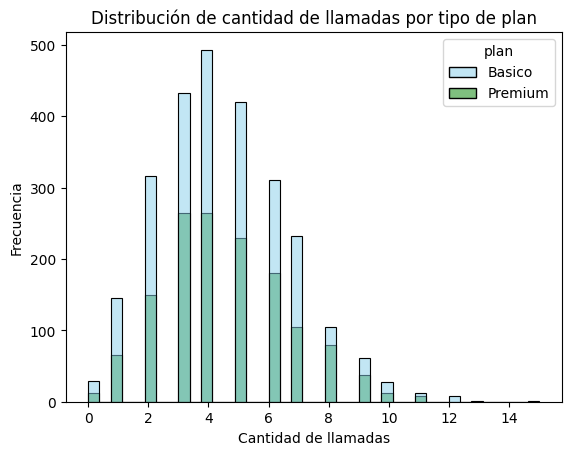

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Distribución sesgada a la derecha: la mayoría hace pocas llamadas, pocos usuarios hacen muchas.

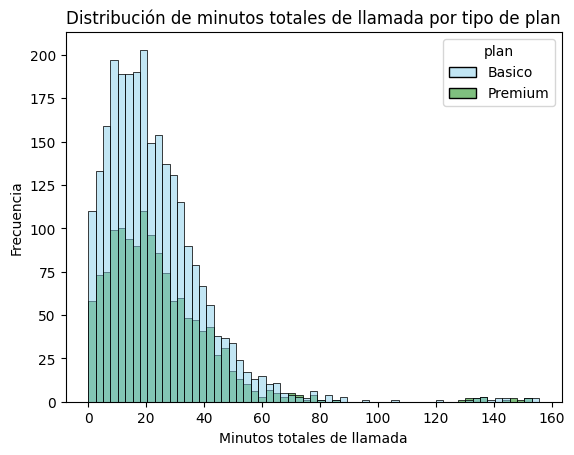

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de minutos totales de llamada por tipo de plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Sigue el mismo patrón sesgado que cant_llamadas, esperado ya que están relacionadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

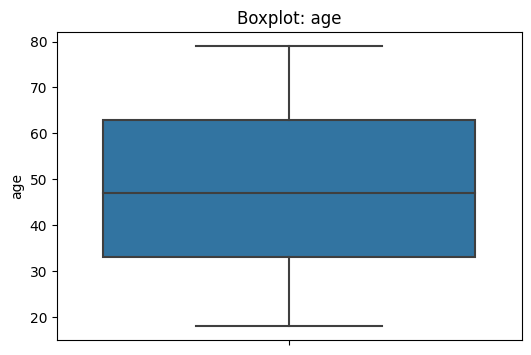

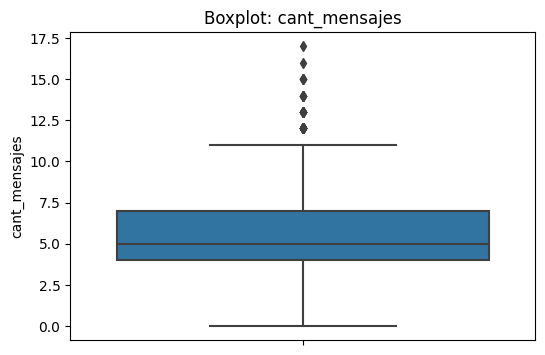

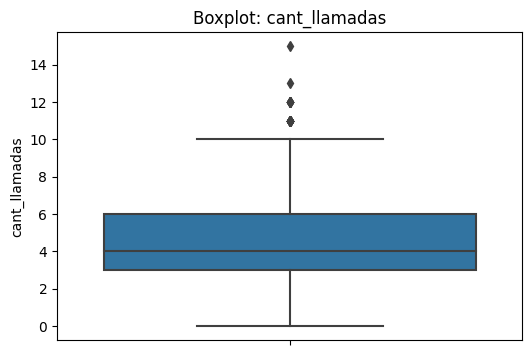

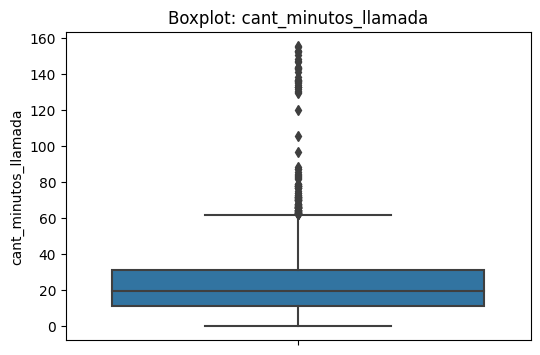

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: no presenta outliers. El boxplot muestra los bigotes llegando limpiamente hasta el mínimo (18) y máximo (79) sin ningún punto fuera de rango, coherente con que ya limpiamos el sentinel -999.
- cant_mensajes: sí presenta outliers, con varios usuarios por encima de ~11-12 mensajes, llegando hasta 17.
- cant_llamadas: sí presenta outliers, con algunos usuarios entre 11 y 15 llamadas, por encima del resto del grupo.
- cant_minutos_llamada: sí presenta outliers, y son los más marcados de las cuatro variables — varios usuarios superan los 60 minutos, con casos que llegan hasta 155.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}: límite inferior = {limite_inferior:.2f}, límite superior = {limite_superior:.2f}")

cant_mensajes: límite inferior = -0.50, límite superior = 11.50
cant_llamadas: límite inferior = -1.50, límite superior = 10.50
cant_minutos_llamada: límite inferior = -19.32, límite superior = 61.86


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?

- cant_llamadas: mantener o no outliers, porqué?

- cant_minutos_llamada: mantener o no outliers, porqué?

RTA/

cant_mensajes: mantener los outliers. Enviar entre 12 y 17 mensajes no es un valor imposible ni un error de captura, es simplemente un grupo de usuarios con mayor actividad de mensajería. Eliminarlos haría perder información valiosa para identificar clientes de alto consumo.

- cant_llamadas: mantener los outliers. Al igual que con los mensajes, hacer entre 11 y 15 llamadas es un comportamiento real y plausible, no un dato inválido. Este grupo puede representar usuarios con necesidades diferenciadas (por ejemplo, uso más intensivo del servicio de voz).

- cant_minutos_llamada: mantener los outliers, aunque con una salvedad. La mayoría de los casos entre 62 y ~100 minutos son razonables para usuarios de alto consumo. Sin embargo, los valores más extremos (cercanos a 150-155 minutos) se recomienda revisarlos puntualmente antes de tomar decisiones comerciales sobre ellos, ya que podrían representar clientes corporativos, un error residual de captura, o simplemente el segmento de mayor consumo del negocio — vale la pena diferenciarlos en el análisis de segmentación en vez de descartarlos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

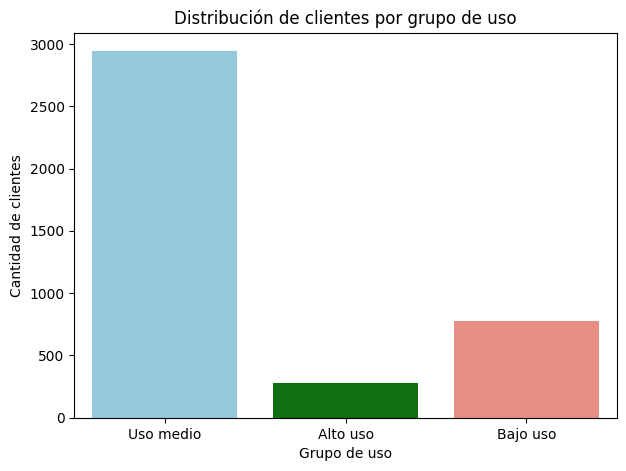

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'green', 'salmon'])
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')
plt.show()

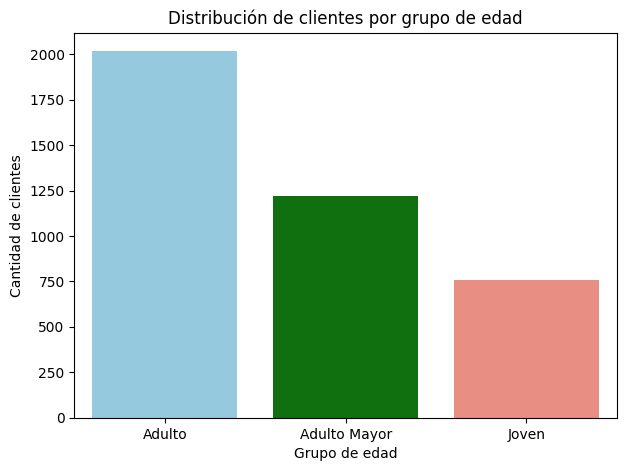

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'salmon'])
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Sentinels y valores inválidos: la columna age contenía el valor -999 como marcador de dato inválido (afectando además el cálculo de la desviación estándar), y la columna city tenía 96 registros con el valor "?" como sentinel de texto, que sumados a los 469 nulos reales representaron un 14.1% de la base de usuarios sin ciudad válida.
Fechas fuera de rango: se encontraron 40 registros de reg_date con año 2026, una fecha imposible dado que el negocio solo tiene datos hasta 2024 (1% de los usuarios).
Nulos estructurales, no errores: las columnas duration y length en usage presentaban 55% y 45% de nulos respectivamente, pero se confirmó mediante el cruce con type que se trata de un patrón esperado (MAR): cada evento es una llamada o un mensaje, nunca ambos, por lo que cada fila usa naturalmente solo una de las dos columnas.


🔍 **Segmentos por Edad**
Se identificaron tres grupos: Joven (<30 años), Adulto (30-59 años) y Adulto Mayor (60+ años).
La distribución de edad es relativamente pareja entre los tres grupos, sin una concentración extrema en ninguno.
No se observó una asociación clara entre edad y tipo de plan contratado (Básico/Premium): ambos planes tienen una composición etaria similar, lo que sugiere que la decisión de plan no está impulsada principalmente por la edad del cliente.


📊 **Segmentos por Nivel de Uso**

Se identificaron tres grupos: Bajo uso, Uso medio y Alto uso, según combinación de llamadas y mensajes.
La mayoría de los usuarios se concentra en llamadas y mensajes moderados (3-7 mensajes, 3-6 llamadas), con una distribución sesgada a la derecha en ambas variables — es decir, hay una cola de usuarios con consumo notablemente superior al promedio.
Se detectaron outliers de alto consumo en las tres variables de uso (cant_mensajes, cant_llamadas, cant_minutos_llamada), especialmente marcados en minutos de llamada, donde algunos usuarios superan los 150 minutos frente a una mediana de ~20.


➡️ Esto sugiere que el "Alto uso" no es un grupo marginal o error de datos, sino un segmento real y diferenciado de clientes con necesidades de consumo muy superiores al resto — un target claro para ofertas específicas, en lugar de tratarlos con el mismo plan estándar que la mayoría de la base.


💡 **Recomendaciones**

Crear un plan intermedio o "Alto Consumo" dirigido específicamente al segmento de Alto uso, con más minutos y mensajes incluidos, para reducir el riesgo de que estos clientes migren a la competencia por sentirse limitados en su plan actual.
Investigar puntualmente los casos extremos de cant_minutos_llamada (100-155 min) antes de incluirlos en campañas masivas, para distinguir entre clientes de alto valor genuino y posibles errores de registro residuales.
No usar la edad como criterio principal de segmentación de oferta, dado que no mostró una relación clara con el tipo de plan o el nivel de uso; en cambio, priorizar el comportamiento de consumo real (grupo_uso) como eje central de las estrategias comerciales.
Estandarizar la captura de city en los sistemas de registro de ConnectaTel, dado que un 14.1% de los usuarios no tiene ciudad válida — esto limita hoy la capacidad de hacer análisis geográficos más finos (por ejemplo, diferencias de consumo entre México y Colombia).

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`